# Module 5 · Lecture C10 — Machine Learning for MR Image Reconstruction

*Computational MRI (CMRI), FAU Erlangen-Nürnberg · "MRI: Zero to Hero" · Day 33*

This is the lecture where deep learning enters the scanner. We have spent Modules 1–4 learning the **classical** pipeline: physics → k-space → FFT → accelerated reconstruction (SENSE, GRAPPA, compressed sensing). This lecture asks: **what if we let a neural network do the reconstruction instead?**

The whole lecture hangs on one equation you already know from compressed sensing:

$$\hat{u} \;=\; \arg\min_{u}\; \tfrac{\lambda}{2}\,\lVert Au - f\rVert_2^2 \;+\; \mathcal{R}(u)$$

- $u$ — the image we want.
- $f$ — the acquired (under-sampled, noisy) k-space data.
- $A$ — the **forward operator** (coil sensitivities × Fourier transform × sampling mask). $f = Au$.
- $\tfrac{\lambda}{2}\lVert Au-f\rVert_2^2$ — **data consistency**: the reconstruction must explain what we measured.
- $\mathcal{R}(u)$ — the **regularizer / prior**: what a "plausible" image looks like.

Classical CS *hand-designs* $\mathcal{R}$ (e.g. sparsity in wavelets, total variation). The big idea of this lecture: **learn the prior — or the whole solver — from data.**

By the end you will have implemented and compared four reconstructions on the same under-sampled data:

1. **Zero-filling** (the do-nothing baseline)
2. **CS-TV** (classical compressed sensing)
3. **Image-domain post-processing CNN** (Approach 1)
4. **Unrolled variational network** (Approach 3)

…and you will have *seen a network hallucinate* — the single most important safety lesson of the lecture.

> **Runtime note.** Defaults are tuned to run on a laptop CPU in ~2 minutes (48×48 images, 96 training phantoms, 25 epochs). On a GPU / Colab, bump `N`, dataset size, and epochs for sharper results.


In [1]:
import numpy as np, torch, torch.nn as nn, time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn

torch.manual_seed(0); np.random.seed(0)
DEVICE = 'cpu'
print('torch', torch.__version__, '| device', DEVICE)

torch 2.11.0+cpu | device cpu


## 1 · The forward operator $A$ and its inverse

In MRI we never measure the image directly. We measure its Fourier transform along a sampling trajectory. For a centered 2-D Cartesian acquisition the (single-coil) signal equation from the slide is

$$f(k_x,k_y)=\iint u(x,y)\,e^{-i(k_x x + k_y y)}\,dx\,dy \quad\Longleftrightarrow\quad f = Au,\qquad u = A^{-1}f.$$

So $A$ is just a **centered FFT** (plus, later, a sampling mask and coil sensitivities). We implement the *unitary* centered transform pair `fft2c` / `ifft2c`. Because they are unitary, the **adjoint equals the inverse** ($A^{H}=A^{-1}$ on fully-sampled data), which is exactly what the gradient-descent reconstruction will need.

In [2]:
def fft2c(x):
    return torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(x, dim=(-2,-1)), norm='ortho'), dim=(-2,-1))
def ifft2c(k):
    return torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(k, dim=(-2,-1)), norm='ortho'), dim=(-2,-1))

def show(imgs, titles=None, cmap='gray', vmax=None):
    arr = [(i if isinstance(i, np.ndarray) else i.detach().abs().cpu().numpy()) for i in imgs]
    fig, ax = plt.subplots(1, len(arr), figsize=(2.7*len(arr), 2.9))
    if len(arr) == 1: ax = [ax]
    for j, a in enumerate(ax):
        a.imshow(arr[j], cmap=cmap, vmax=vmax); a.axis('off')
        if titles: a.set_title(titles[j], fontsize=9)
    plt.tight_layout(); plt.show()

### A synthetic phantom and its k-space

We work on synthetic phantoms (random ellipses) so everything is self-contained and fast. They are *piecewise-smooth*, like real anatomy, so total-variation and learned priors behave realistically. The "try it on real data" path is the **fastMRI** dataset (Section 10).

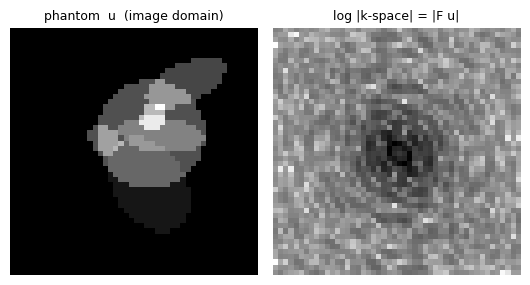

In [3]:
def random_phantom(n=48, k=6, rng=None):
    rng = rng or np.random.default_rng()
    yy, xx = np.mgrid[-1:1:n*1j, -1:1:n*1j]
    img = np.zeros((n, n))
    for _ in range(k):
        cx, cy = rng.uniform(-.6, .6, 2); a, b = rng.uniform(.1, .45, 2); th = rng.uniform(0, np.pi)
        xr =  (xx-cx)*np.cos(th) + (yy-cy)*np.sin(th)
        yr = -(xx-cx)*np.sin(th) + (yy-cy)*np.cos(th)
        img[(xr/a)**2 + (yr/b)**2 <= 1] += rng.uniform(.2, 1.0)
    img = np.clip(img, 0, None)
    if img.max() > 0: img /= img.max()
    return img.astype(np.float32)

N = 48
u = torch.tensor(random_phantom(N, rng=np.random.default_rng(0)))
k = fft2c(u.to(torch.cfloat))
show([u, torch.log(k.abs()+1e-3)], ['phantom  u  (image domain)', 'log |k-space| = |F u|'])

## 2 · Under-sampling → aliasing

Acceleration means **skipping k-space lines**. We multiply the full k-space by a binary sampling **mask** $M$, so the operator becomes $A = M\,F$ and the measurement is $f = MFu$.

Two mask styles, two artifact characters — exactly the slide showing $\Delta k_y \to 2\Delta k_y$:

- **Regular** under-sampling (every $R$-th line) → **coherent** aliasing: the FOV folds, you get $R$ crisp overlapping copies. This is what SENSE/GRAPPA were built to undo.
- **Variable-density random** under-sampling → **incoherent**, noise-like artifacts. This is what compressed sensing and most learned methods assume.

A small fully-sampled **ACS** (auto-calibration) block at the center is kept in both — it anchors low-frequency contrast and is what parallel-imaging calibration uses.

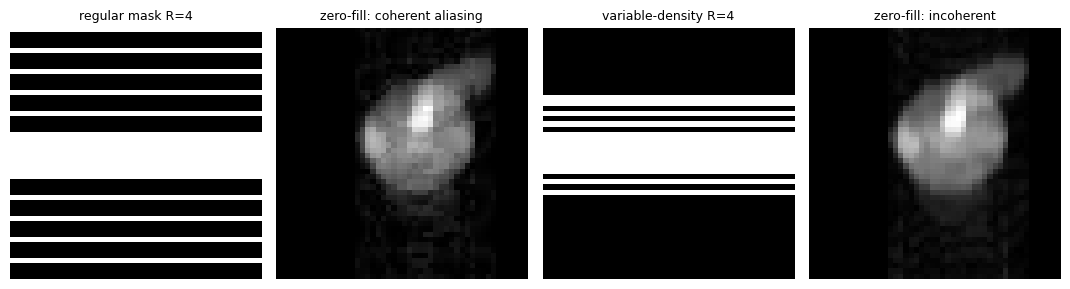

In [4]:
def mask_regular(n, R, acs=8):
    m = np.zeros(n); m[::R] = 1; c = n//2; m[c-acs//2:c+acs//2] = 1
    return torch.tensor(np.tile(m[:,None], (1, n)), dtype=torch.float32)

def mask_vardens(n, R, acs=8, rng=None):
    rng = rng or np.random.default_rng(); c = n//2
    p = np.exp(-0.5*((np.arange(n)-c)/(n/6))**2); p /= p.sum()
    keep = max(1, int(n/R)); idx = rng.choice(n, size=keep, replace=False, p=p)
    m = np.zeros(n); m[idx] = 1; m[c-acs//2:c+acs//2] = 1
    return torch.tensor(np.tile(m[:,None], (1, n)), dtype=torch.float32)

mreg = mask_regular(N, 4)
mvd  = mask_vardens(N, 4, rng=np.random.default_rng(3))
zf_reg = ifft2c(mreg * fft2c(u.to(torch.cfloat)))
zf_vd  = ifft2c(mvd  * fft2c(u.to(torch.cfloat)))
show([mreg, zf_reg, mvd, zf_vd],
     ['regular mask R=4', 'zero-fill: coherent aliasing', 'variable-density R=4', 'zero-fill: incoherent'])

### Measurement model + the metrics we will live by

`measure()` applies the mask and adds complex Gaussian noise — our $f$. We score reconstructions with three numbers used throughout the literature and the fastMRI challenge:

- **NRMSE** — normalized error (lower is better)
- **PSNR** — peak SNR in dB (higher better)
- **SSIM** — structural similarity, the metric the **fastMRI challenge ranked on** because it tracks perceived quality better than MSE (higher better)

We carry complex images as **2 real channels** (real, imaginary) so ordinary `Conv2d` layers can process them.

In [5]:
def measure(u, mask, noise=0.0, rng=None):
    k = mask * fft2c(u)
    if noise > 0:
        rng = rng or np.random.default_rng()
        nse = torch.tensor(rng.normal(0, noise, k.shape) + 1j*rng.normal(0, noise, k.shape), dtype=torch.cfloat)
        k = k + mask * nse
    return k

def c2ch(x): return torch.stack([x.real, x.imag], -3)            # complex -> 2 channels
def ch2c(x): return torch.complex(x[..., 0, :, :], x[..., 1, :, :])  # 2 channels -> complex

def nrmse(a, b): return float(torch.norm(a-b) / torch.norm(b))
def psnr(a, b):
    mse = float(torch.mean((a-b).abs()**2)); mx = float(b.abs().max())
    return 10*np.log10(mx**2 / mse)
def ssim(a, b):
    A = a.detach().abs().cpu().numpy(); B = b.detach().abs().cpu().numpy()
    return float(ssim_fn(A, B, data_range=B.max()-B.min()))

## 3 · Classical baseline — compressed sensing (CS-TV)

Before any learning, reproduce the CS slide. We minimize

$$\min_u\; \tfrac{\lambda}{2}\lVert Au-f\rVert_2^2 \;+\; \lambda\,\mathrm{TV}(u)$$

with **gradient descent** — the Landweber iteration from the slide:

$$u_t = u_{t-1} - \frac{\partial}{\partial u}\Big(\tfrac{\lambda}{2}\lVert Au_{t-1}-f\rVert_2^2 + \mathcal{R}(u_{t-1})\Big).$$

Here $\mathcal{R}=\mathrm{TV}$ is the **hand-crafted** prior (total variation = sum of gradient magnitudes; it likes piecewise-constant images). Remember this iteration — Approach 3 will *learn* it.

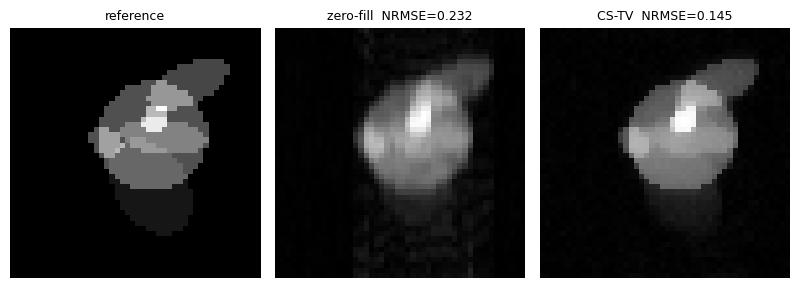

In [6]:
def cs_tv(f, mask, lam=0.02, iters=80, lr=0.1):
    u = ifft2c(f).clone().requires_grad_(True)          # start from zero-filling
    opt = torch.optim.Adam([u], lr=lr)
    for _ in range(iters):
        opt.zero_grad()
        dc = 0.5*((mask*fft2c(u) - f).abs()**2).sum()    # data consistency
        tv = (u[1:,:]-u[:-1,:]).abs().sum() + (u[:,1:]-u[:,:-1]).abs().sum()  # total variation
        (dc + lam*tv).backward(); opt.step()
    return u.detach()

mask = mask_vardens(N, 4, acs=8, rng=np.random.default_rng(3))
gt   = u.to(torch.cfloat)
f    = measure(gt, mask, noise=0.008, rng=np.random.default_rng(1))
zf   = ifft2c(f)
rec  = cs_tv(f, mask, lam=0.02, iters=80)
show([gt, zf, rec],
     ['reference', f'zero-fill  NRMSE={nrmse(zf,gt):.3f}', f'CS-TV  NRMSE={nrmse(rec,gt):.3f}'])

> **Exercise 1.** The regularization weight $\lambda$ trades data-fidelity against smoothness. Sweep `lam` over `[0.0, 0.005, 0.02, 0.08]` and report NRMSE/PSNR. What happens at $\lambda=0$ (pure data consistency)? At very large $\lambda$? — *Solution below.*

In [7]:
# --- Solution 1 ---
for lam in [0.0, 0.005, 0.02, 0.08]:
    r = cs_tv(f, mask, lam=lam, iters=80)
    print(f'lambda={lam:<6}  NRMSE={nrmse(r,gt):.3f}  PSNR={psnr(r,gt):.2f} dB')
# lambda=0  -> no prior, the missing lines stay ~0: basically zero-filling (noisy, aliased).
# small lambda -> best balance.  large lambda -> over-smoothed, edges/fine detail washed out
# (NRMSE rises again). This U-shaped behaviour is THE reason we want to *learn* the prior.

lambda=0.0     NRMSE=0.277  PSNR=25.28 dB
lambda=0.005   NRMSE=0.104  PSNR=33.77 dB
lambda=0.02    NRMSE=0.145  PSNR=30.89 dB
lambda=0.08    NRMSE=0.214  PSNR=27.50 dB


## 4 · The three deep-learning approaches

The lecture organizes learned reconstruction by **where the network sits** in the pipeline $f \xrightarrow{\mathcal F^{-1}} \text{image}$:

| | Approach | Network input → output | Examples from the slides |
|---|---|---|---|
| **1** | **Image-domain post-processing** | aliased image → clean image | FBPConvNet (Jin 2017); Gibbs-removal U-Net (Muckley MRM 2020) |
| **2** | **k-space recovery** | gappy k-space → full k-space | RAKI (Akçakaya 2019), AUTOMAP (Zhu 2018) |
| **3** | **Unrolled iterative reconstruction** | k-space + physics → image, *inside* the optimizer | Variational Network (Hammernik MRM 2018) |

Approach 1 is the easiest to train but **ignores the physics after the FFT**. Approach 3 keeps the forward operator $A$ in the loop at every step and consistently wins — at the cost of being heavier. We will train Approaches 1 and 3, and visualize where Approach 2 operates.

First, a shared dataset and a shared training loop.

In [8]:
def make_dataset(Nimg, n, mask, noise=0.008, seed=0, lesion=False):
    rng = np.random.default_rng(seed); imgs = []
    for _ in range(Nimg):
        im = random_phantom(n, rng=rng)
        if lesion:  # plant a small focal 'lesion' the network will NOT see during training
            cy, cx = rng.integers(int(0.3*n), int(0.7*n), 2); yy, xx = np.mgrid[0:n, 0:n]
            im = np.clip(im + 0.35*np.exp(-((yy-cy)**2+(xx-cx)**2)/(2*1.5**2)), 0, 1.3).astype(np.float32)
        imgs.append(torch.tensor(im))
    gt = torch.stack(imgs).to(torch.cfloat)
    f  = torch.stack([measure(g, mask, noise=noise, rng=rng) for g in gt]); zf = ifft2c(f)
    return gt, f, zf

mask = mask_vardens(N, 4, acs=8, rng=np.random.default_rng(3))
gt_tr, f_tr, zf_tr = make_dataset(96, N, mask, seed=7)    # training set (no lesions)
gt_te, f_te, zf_te = make_dataset(24, N, mask, seed=99)   # test set
print('train', tuple(gt_tr.shape), '| test', tuple(gt_te.shape),
      '| sampled fraction', round(float(mask[:,0].mean()), 3), '-> R_eff', round(1/float(mask[:,0].mean()), 2))

def train(net, forward_fn, epochs=25, bs=16, lr=1e-3):
    opt = torch.optim.Adam(net.parameters(), lr); Nt = gt_tr.shape[0]
    for ep in range(epochs):
        perm = torch.randperm(Nt)
        for i in range(0, Nt, bs):
            idx = perm[i:i+bs]; opt.zero_grad()
            loss = ((forward_fn(net, idx) - gt_tr[idx]).abs()**2).mean()   # supervised L2 on complex image
            loss.backward(); opt.step()
    return loss.item()

train (96, 48, 48) | test (24, 48, 48) | sampled fraction 0.292 -> R_eff 3.43


## 5 · Approach 1 — image-domain post-processing CNN

Take the aliased zero-filled image and let a CNN clean it up. This is pure image-to-image learning; the loss is

$$\mathcal{L}(\Theta)=\tfrac{1}{S}\sum_{s=1}^{S}\big\lVert \mathrm{CNN}_\Theta(u^{\text{zf}}_s) - u^{\text{ref}}_s\big\rVert_2^2,$$

the supervised loss from the **Hammernik MRM 2018** "learning for reconstruction" slide. We use a small **U-Net** (the architecture on the Muckley/Jin slides) with a **residual** output — the network learns the *artifact* and subtracts it, which trains faster and is the FBPConvNet trick.

In [9]:
class ConvBlk(nn.Module):
    def __init__(s, i, o):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.ReLU(True),
                            nn.Conv2d(o, o, 3, padding=1), nn.ReLU(True))
    def forward(s, x): return s.n(x)

class UNet(nn.Module):
    def __init__(s, ch=2, base=16):
        super().__init__()
        s.d1 = ConvBlk(ch, base); s.d2 = ConvBlk(base, base*2); s.bott = ConvBlk(base*2, base*4)
        s.u2 = ConvBlk(base*4+base*2, base*2); s.u1 = ConvBlk(base*2+base, base)
        s.out = nn.Conv2d(base, ch, 1); s.pool = nn.MaxPool2d(2)
        s.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
    def forward(s, x):
        d1 = s.d1(x); d2 = s.d2(s.pool(d1)); b = s.bott(s.pool(d2))
        v = s.u2(torch.cat([s.up(b), d2], 1)); v = s.u1(torch.cat([s.up(v), d1], 1))
        return x + s.out(v)            # residual: learn the artifact, subtract it

t = time.time(); unet = UNet(base=16)
loss = train(unet, lambda net, idx: ch2c(net(c2ch(zf_tr[idx]))), epochs=25)
print(f'post-processing U-Net trained in {time.time()-t:.0f}s | final loss {loss:.5f}')

post-processing U-Net trained in 32s | final loss 0.00249


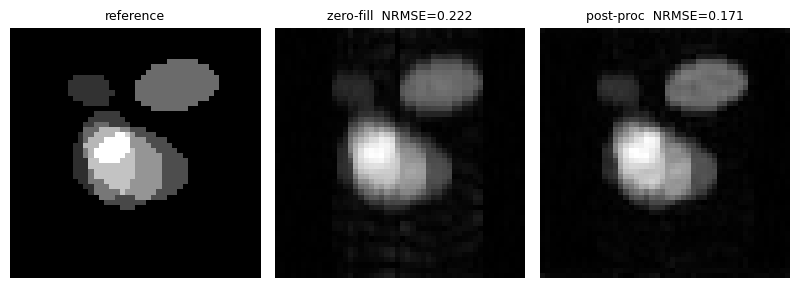

mean test NRMSE   zero-fill 0.248   post-proc 0.194


In [10]:
with torch.no_grad():
    pp = ch2c(unet(c2ch(zf_te)))
i = 0
show([gt_te[i], zf_te[i], pp[i]],
     ['reference', f'zero-fill  NRMSE={nrmse(zf_te[i],gt_te[i]):.3f}', f'post-proc  NRMSE={nrmse(pp[i],gt_te[i]):.3f}'])
print('mean test NRMSE   zero-fill', round(float(np.mean([nrmse(zf_te[j],gt_te[j]) for j in range(24)])), 3),
      '  post-proc', round(float(np.mean([nrmse(pp[j],gt_te[j]) for j in range(24)])), 3))

> **Exercise 2.** Approach 1 throws away the measured data after the FFT — the output need not even be consistent with $f$. Add a **hard data-consistency** step *after* the CNN: in k-space, keep the measured lines and only trust the network for the gaps,
> $$\hat k = (1-M)\,F\,u_{\text{cnn}} + M\,f,\qquad \hat u = F^{-1}\hat k.$$
> Does enforcing consistency change the error? — *Solution below.*

In [11]:
# --- Solution 2 ---
def data_consistency(u, f, mask):
    k = fft2c(u); k = (1-mask)*k + mask*f      # keep measured k-space, fill gaps with the network
    return ifft2c(k)

with torch.no_grad():
    pp_dc = torch.stack([data_consistency(pp[j], f_te[j], mask) for j in range(24)])
print('post-proc            mean NRMSE', round(float(np.mean([nrmse(pp[j],   gt_te[j]) for j in range(24)])), 3))
print('post-proc + hard DC  mean NRMSE', round(float(np.mean([nrmse(pp_dc[j],gt_te[j]) for j in range(24)])), 3))
# Re-injecting the true measured lines pins the recon to real data and usually nudges the error down.
# This little DC layer is exactly the seed of Approach 3 -- where DC is applied at EVERY step.

post-proc            mean NRMSE 0.194
post-proc + hard DC  mean NRMSE 0.185


## 6 · Approach 2 — k-space recovery (where it lives)

Instead of cleaning the image, learn to **fill the missing k-space lines directly**, then a single inverse FFT gives the image. This is the home of:

- **GRAPPA** (Module 4, C06) — a *linear* learned kernel that synthesizes missing lines from neighbors using the ACS region.
- **RAKI** (Akçakaya MRM 2019) — GRAPPA made nonlinear with a small **scan-specific** CNN trained on that scan's own ACS data — *database-free*, so no risk of a training-set bias.
- **AUTOMAP** (Zhu 2018) — learns the entire k-space→image transform end-to-end.

The visualization below shows the operands: full k-space, the mask, and the gappy k-space the network must complete. (We don't train a single-coil version here because k-space interpolation is only powerful with multiple coils — that's the parallel-imaging story from Module 4.)

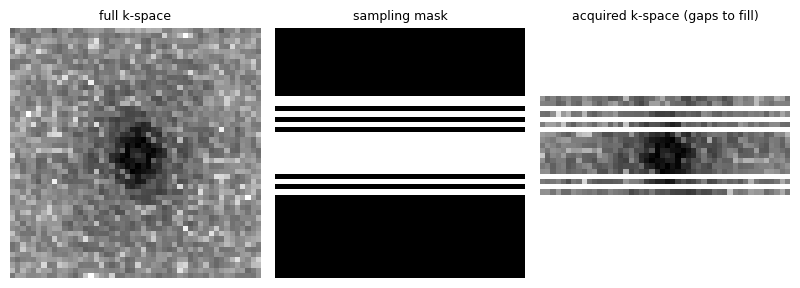

In [12]:
kfull = fft2c(gt_te[0])
show([torch.log(kfull.abs()+1e-3), mask, torch.log((mask*kfull).abs()+1e-3)],
     ['full k-space', 'sampling mask', 'acquired k-space (gaps to fill)'])

## 7 · Approach 3 — unrolled / variational network (the winner)

This is the heart of the lecture and the slide titled *"Learning Gradient Descent."* Start from the CS gradient-descent step and **replace the hand-crafted regularizer gradient with learned filters**. The slide's update is

$$u_t = u_{t-1} - \underbrace{\sum_{i=1}^{N} K_{i,t}^{\top}\,\rho'_{i,t}\!\big(K_{i,t}\,u_{t-1}\big)}_{\text{learned regularization gradient}} - \underbrace{\lambda_t\,A^{H}\!\big(A u_{t-1}-f\big)}_{\text{data-consistency gradient}}.$$

We **unroll** $T$ such steps into a network and train them **end-to-end** — every block is one "learned GD step," and the stack is Hammernik's **variational network (VN)**. Two things make it strong:

- The forward operator $A$ (the physics) is applied at **every** step, so the result stays data-consistent — unlike Approach 1.
- Each step has its **own** CNN $\Rightarrow$ the prior is learned and stage-specific. Here a small CNN plays the role of $\sum_i K_i^{\top}\rho'(K_i\cdot)$.

In [13]:
class Reg(nn.Module):
    # learned regularization gradient: stands in for  sum_i K_i^T rho'(K_i u)
    def __init__(s, base=16):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(2, base, 3, padding=1), nn.ReLU(True),
                            nn.Conv2d(base, base, 3, padding=1), nn.ReLU(True),
                            nn.Conv2d(base, 2, 3, padding=1))
    def forward(s, x): return s.n(x)

class VarNet(nn.Module):
    # Unrolled gradient descent (Hammernik MRM 2018): T learned GD steps, physics in the loop.
    def __init__(s, T=5, base=16):
        super().__init__()
        s.regs = nn.ModuleList([Reg(base) for _ in range(T)])
        s.lam  = nn.Parameter(torch.ones(T)*0.5)   # learnable step sizes lambda_t
        s.T = T
    def forward(s, u0, f, mask):
        u = u0
        for t in range(s.T):
            grad_dc = ifft2c(mask*fft2c(u) - f)        # A^H (A u - f)
            reg     = ch2c(s.regs[t](c2ch(u)))         # learned regularizer gradient
            u = u - s.lam[t]*grad_dc - reg
        return u

t = time.time(); vnet = VarNet(T=5, base=16)
loss = train(vnet, lambda net, idx: net(zf_tr[idx], f_tr[idx], mask), epochs=25)
print(f'variational network trained in {time.time()-t:.0f}s | final loss {loss:.5f}')
print('learned step sizes lambda_t:', [round(x, 2) for x in vnet.lam.detach().tolist()])

variational network trained in 30s | final loss 0.00100
learned step sizes lambda_t: [0.5, 0.54, 0.53, 0.52, 0.52]


### Head-to-head: all four reconstructions on the same test data

zero-fill        NRMSE 0.248   PSNR 24.45 dB   SSIM 0.607
CS-TV            NRMSE 0.127   PSNR 30.31 dB   SSIM 0.752
post-proc CNN    NRMSE 0.194   PSNR 26.60 dB   SSIM 0.655
unrolled VN      NRMSE 0.124   PSNR 30.46 dB   SSIM 0.842


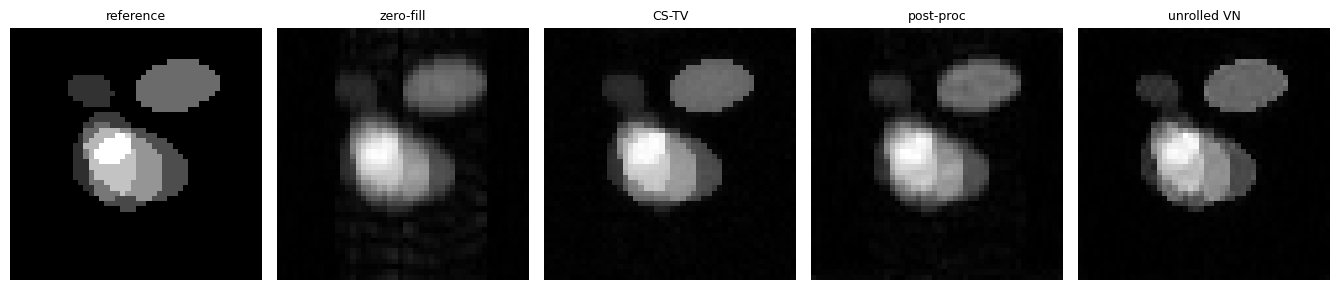

In [14]:
with torch.no_grad():
    vn = vnet(zf_te, f_te, mask)
cs = torch.stack([cs_tv(f_te[j], mask, lam=0.02, iters=80) for j in range(24)])

def report(name, a):
    print(f'{name:<16} NRMSE {np.mean([nrmse(a[j],gt_te[j]) for j in range(24)]):.3f}'
          f'   PSNR {np.mean([psnr(a[j],gt_te[j]) for j in range(24)]):5.2f} dB'
          f'   SSIM {np.mean([ssim(a[j],gt_te[j]) for j in range(24)]):.3f}')
report('zero-fill', zf_te); report('CS-TV', cs); report('post-proc CNN', pp); report('unrolled VN', vn)

i = 0
show([gt_te[i], zf_te[i], cs[i], pp[i], vn[i]],
     ['reference', 'zero-fill', 'CS-TV', 'post-proc', 'unrolled VN'])

You should see the ordering from the lecture's *"PI → PI-CS → Learning"* comparison slides: **zero-fill (worst) → CS-TV → post-processing → unrolled VN (best)**. The VN keeps physics in the loop, so it sharpens edges *without* drifting away from the measured data.

> **Exercise 3.** The number of unrolled stages $T$ is the network's "iteration count." Train VNs with `T = 1, 3, 5, 8` (20 epochs each) and report NRMSE vs $T$. Where do the gains saturate? (This mirrors the Vornehm ISMRM 2023 *stages-vs-quality* table.) — *Solution below.*

In [15]:
# --- Solution 3 ---
for T in [1, 3, 5, 8]:
    net = VarNet(T=T, base=16)
    train(net, lambda nt, idx: nt(zf_tr[idx], f_tr[idx], mask), epochs=20)
    with torch.no_grad():
        r = net(zf_te, f_te, mask)
    print(f'T={T}:  NRMSE {np.mean([nrmse(r[j],gt_te[j]) for j in range(24)]):.3f}')
# More stages -> lower error, but with diminishing returns and rising compute -- exactly the
# accuracy/latency trade-off the lecture shows for real-time cardiac cine.

T=1:  NRMSE 0.179
T=3:  NRMSE 0.153
T=5:  NRMSE 0.130
T=8:  NRMSE 0.117


## 8 · The dark side — when learned reconstruction lies

This is the most important part of the lecture. Learned reconstructions are not a free lunch; the slides flag three failure modes. We reproduce two of them.

### 8a · Out-of-distribution acceleration (Radmanesh 2022)
A network trained at $R=4$ is shown $R=8$ data — **more acceleration than it ever saw**. Error jumps and detail collapses, just like the *"performance at progressive acceleration"* slide.

VN trained @R=4   ->  test R=4 NRMSE 0.124   |  test R=8 (OOD) NRMSE 0.233


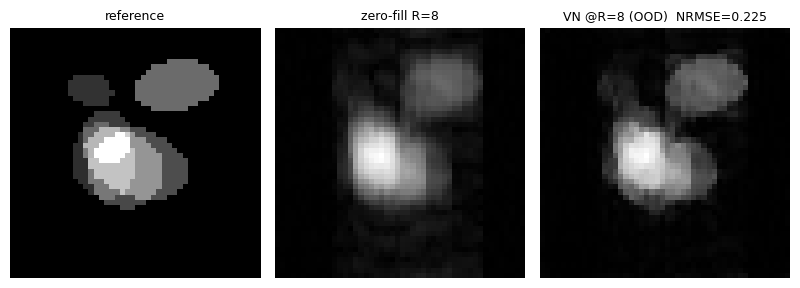

In [16]:
mask8 = mask_vardens(N, 8, acs=6, rng=np.random.default_rng(3))
gt_o, f8, zf8 = make_dataset(24, N, mask8, seed=99)   # SAME phantoms, but R=8 sampling
with torch.no_grad():
    r4 = vnet(zf_te, f_te, mask)     # in-distribution R=4
    r8 = vnet(zf8,  f8,  mask8)      # OOD R=8 (network was trained only on R=4)
print('VN trained @R=4   ->  test R=4 NRMSE',
      round(float(np.mean([nrmse(r4[j],gt_te[j]) for j in range(24)])), 3),
      '  |  test R=8 (OOD) NRMSE',
      round(float(np.mean([nrmse(r8[j],gt_o[j]) for j in range(24)])), 3))
show([gt_o[0], zf8[0], r8[0]],
     ['reference', 'zero-fill R=8', f'VN @R=8 (OOD)  NRMSE={nrmse(r8[0],gt_o[0]):.3f}'])

### 8b · Unseen features / hallucination (Muckley TMI 2021)
The slide's chilling note: *"acceleration was too high → a disease was removed."* A network has only ever seen its training distribution. Feed it a small focal **lesion** it never encountered, and it may **smooth it away** (false negative) or **invent** structure that was not there (false positive). We train on lesion-free phantoms, then reconstruct phantoms that contain a small lesion — and *inspect* whether the lesion survives.

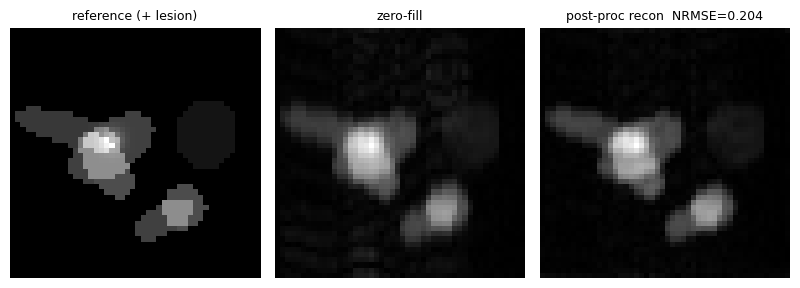

In [17]:
gt_l, f_l, zf_l = make_dataset(6, N, mask, seed=55, lesion=True)   # phantoms WITH a small lesion
with torch.no_grad():
    rec_l = ch2c(unet(c2ch(zf_l)))   # unet never saw a lesion in training
i = 0
show([gt_l[i], zf_l[i], rec_l[i]],
     ['reference (+ lesion)', 'zero-fill', f'post-proc recon  NRMSE={nrmse(rec_l[i],gt_l[i]):.3f}'])

> **Exercise 4.** The global NRMSE can look *fine* even when a clinically critical lesion is mangled — error metrics average over the whole image. Crop a window around the lesion in (reference, zero-fill, recon) and compare the peak intensity at the lesion location. Is the lesion faithfully recovered, blurred, or removed? — *Solution below.*

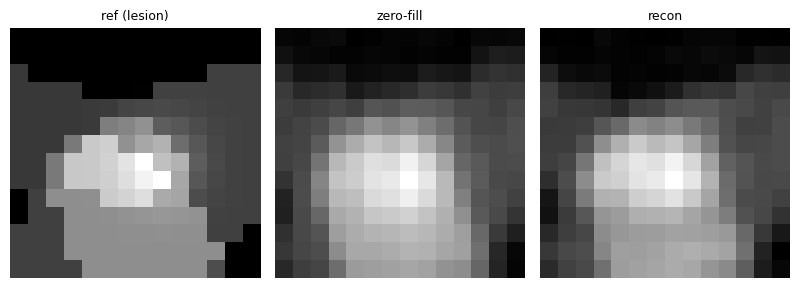

peak intensity   reference 1.28    recon-at-lesion 1.137


In [18]:
# --- Solution 4 ---
i = 0; ref = gt_l[i].abs().numpy()
yy, xx = np.unravel_index(np.argmax(ref), ref.shape); s = 7
crop = lambda im: im.detach().abs().numpy()[max(0,yy-s):yy+s, max(0,xx-s):xx+s]
show([crop(gt_l[i]), crop(zf_l[i]), crop(rec_l[i])], ['ref (lesion)', 'zero-fill', 'recon'])
print('peak intensity   reference', round(float(gt_l[i].abs().max()), 3),
      '   recon-at-lesion', round(float(rec_l[i].abs()[yy, xx]), 3))
# Whether the lesion is preserved depends on its contrast vs. the training distribution.
# The lesson is NOT 'this run removed it' -- it is that you cannot trust a global metric to
# tell you. This is why the field moved toward uncertainty maps and clinical reader studies.

## 9 · Beyond supervised learning (no code — orientation for further study)

The lecture's later slides survey methods that drop the need for fully-sampled references or add safety:

- **Self-supervised, no clean targets.** *Noise2Noise / Noise2Self / Noise2Void / Noise2Recon*; **SSDU** (Yaman 2020) splits the acquired k-space into a part to fit and a part to validate — *train from under-sampled data alone*. **Zero-shot** variants and **Deep Image Prior** (Ulyanov) fit a single scan with no training database at all.
- **Generative priors.** **GANs** with cyclic loss; **score-based diffusion models** (Chung & Ye) that sample plausible images consistent with $f$; **plug-and-play** methods that drop a pretrained denoiser into the CS iteration.
- **Architectures.** **Transformers** for fast MRI; cascades of CNNs (Schlemper).
- **Uncertainty.** **Bayesian VN** (Narnhofer TMI 2021) outputs a per-pixel **standard-deviation map** — a direct antidote to silent hallucinations: the model tells you *where it is unsure*.

These all reuse the same scaffold you built: a forward operator $A$, a data-consistency term, and a learned prior.

## 10 · Datasets and clinical translation

- **fastMRI** (NYU + Meta AI): fully-sampled raw k-space — **1,398** knee and **7,002** brain cases, plus GE/Philips transfer tracks. This is your *"try it on real data"* target ([fastmri.med.nyu.edu](https://fastmri.med.nyu.edu/)); the GitHub repo ships PyTorch dataloaders and baseline models.
- **Reconstruction challenges** (Knoll MRM 2020; Muckley TMI 2021) ranked submissions by SSIM at $R=4$ and $R=8$ — and surfaced the **hallucination** problem you just saw.
- **First clinical validation** (Johnson Radiology 2023): a learned recon ran on **300 prospectively under-sampled** clinical knee exams; blinded readers agreed with conventional reads at high rates across cartilage, ligament, meniscus and marrow findings — early evidence that, *used within its acceleration range*, learned reconstruction is clinically viable.
- **Already shipping:** Siemens **Deep Resolve**, Philips **SmartSpeed**, GE **AIR Recon DL**, and startups (AIRS Medical, Subtle Medical). Learned reconstruction is in scanners *today*.

### To run this notebook on real fastMRI data
Swap `random_phantom` for a fastMRI slice, build `mask` from the challenge sampling pattern, estimate coil sensitivities $c_k$ and set $A = M\,F\,\text{diag}(c_k)$ (multi-coil), and reuse every cell above unchanged. `sigpy` (Module 4) gives you the multi-coil operators.

## 11 · Key takeaways

1. **One equation rules everything:** $\min_u \tfrac{\lambda}{2}\lVert Au-f\rVert_2^2 + \mathcal{R}(u)$. Classical CS hand-designs $\mathcal{R}$; deep learning **learns** it — or learns the whole solver.
2. **Three places to put the network:** image domain (post-processing), k-space (interpolation/RAKI), or *inside the optimizer* (unrolled/variational). Keeping physics ($A$) in the loop (Approach 3) is what consistently wins.
3. **An unrolled network is just learned gradient descent** — finitely many GD steps with learned regularizers, trained end-to-end.
4. **Learned recon can hallucinate.** It can remove real pathology or invent fake structure, and global metrics (NRMSE/PSNR/SSIM) can hide it. Out-of-distribution acceleration is where it breaks first.
5. **Mitigations exist:** data-consistency layers, self-supervised training (SSDU), uncertainty maps (Bayesian VN), and — non-negotiably — **clinical reader studies**.
6. **This is deployed technology** (Deep Resolve, SmartSpeed, AIR Recon DL), validated by fastMRI challenges and the first prospective clinical studies.

### Self-test questions
1. Why is the **adjoint** $A^{H}$ (not a learned layer) used for the data-consistency gradient in a variational network?
2. What artifact pattern distinguishes **regular** from **variable-density** under-sampling, and why does each suit different reconstruction methods?
3. In the VN update, which term enforces fidelity to the scan and which encodes the learned prior? What is $\lambda_t$ and why make it learnable per stage?
4. Give one concrete clinical scenario where a hallucinated reconstruction could cause harm, and one safeguard that would catch it.
5. How does **SSDU** train a reconstruction network *without any fully-sampled reference*?
6. You trained at $R=4$ but the clinic wants $R=8$ for speed. Predict what happens and name two things you would do before deploying.

➡️ **Next (Day 36):** go deeper on the unrolled family — implement a MoDL-style block with a shared denoiser and a conjugate-gradient data-consistency layer, and compare against this VN.